In [ ]:
visual_assets_data = {
  "meta": {
    "title": "Visualization + Data Statistics",
    "subtitle": "Split-chart assets for ML models, embeddings, confusion matrices and keyword clouds"
  },
}

In [ ]:
import gzip
import json
import math
import os
import re
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import torch
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
)
from tqdm import tqdm
from transformers import BertTokenizer, BertModel

# PySpark 相关
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.classification import (
    DecisionTreeClassifier,
    GBTClassifier,
    LogisticRegression,
    RandomForestClassifier,
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
)
from pyspark.ml.feature import (
    CountVectorizer,
    IDF,
    RegexTokenizer,
    SQLTransformer,
    StopWordsRemover,
    StringIndexer,
    Word2Vec,
)
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.sql import DataFrame, SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, lit, lower, size, trim, udf, when
from pyspark.sql.types import (
    ArrayType,
    DoubleType,
    FloatType,
    IntegerType,
    StringType,
    StructField,
    StructType,
)

In [ ]:
def data():
    # =========================
    # 1. Create SparkSession
    # =========================
    spark = SparkSession.builder \
        .appName("DSOTM_Sentiment_Baseline") \
        .getOrCreate()

    spark.conf.set("spark.sql.shuffle.partitions", "8")

    # =========================
    # 2. Load Data
    # =========================
    file_path = "dsotm_reviews.csv"   # Change this path if needed
    df = spark.read.csv(file_path, header=True, inferSchema=True)

    print("Raw ")
    df.printSchema()
    print("Original sample count:", df.count())
    df.show(5, truncate=100)

    # =========================
    # 3. Data Cleaning
    #    - Keep Review / Rating
    #    - Remove missing values
    #    - Remove duplicates
    #    - Remove empty text
    # =========================
    df = df.select("Review", "Rating")

    df = df.dropna(subset=["Review", "Rating"])
    df = df.dropDuplicates(["Review", "Rating"])

    df = df.withColumn("Review", F.trim(F.col("Review")))
    df = df.filter(F.col("Review") != "")

    # Ensure Rating is double
    df = df.withColumn("Rating", F.col("Rating").cast("double"))
    df = df.dropna(subset=["Rating"])

    print("Cleaned sample count:", df.count())

    # =========================
    # 4. Label Construction
    #    Sentiment labels are generated from Rating
    #    Note: the rule for 3.0 is configurable
    # =========================
    THREE_AS_POSITIVE = True

    if THREE_AS_POSITIVE:
        df = df.withColumn(
            "Sentiment",
            F.when(F.col("Rating") >= 3.0, F.lit("positive")).otherwise(F.lit("negative"))
        )
    else:
        df = df.withColumn(
            "Sentiment",
            F.when(F.col("Rating") > 3.0, F.lit("positive")).otherwise(F.lit("negative"))
        )

    df.groupBy("Sentiment").count().show()

    # =========================
    # 5. Fixed Data Split
    #    To ensure reproducibility, do not use randomSplit directly
    #    Instead, create a stable split key based on content
    # =========================
    df = df.withColumn(
        "split_key",
        (F.abs(F.hash(F.col("Review"), F.col("Rating"))) % 100).cast("int")
    )

    train_df = df.filter(F.col("split_key") < 80)
    test_df = df.filter(F.col("split_key") >= 80)

    print("Training set size:", train_df.count())
    print("Test set size:", test_df.count())

    # =========================
    # 6. Label Encoding
    # =========================
    label_indexer = StringIndexer(
        inputCol="Sentiment",
        outputCol="label",
        handleInvalid="skip"
    )

    # =========================
    # 7. Text Preprocessing
    #    - Lowercase
    #    - Remove non-letter characters
    #    - Tokenize
    #    - Remove stopwords
    # =========================
    train_df = train_df.withColumn(
        "clean_text",
        F.lower(F.regexp_replace(F.col("Review"), r"[^a-zA-Z\s]", " "))
    )

    test_df = test_df.withColumn(
        "clean_text",
        F.lower(F.regexp_replace(F.col("Review"), r"[^a-zA-Z\s]", " "))
    )

    tokenizer = RegexTokenizer(
        inputCol="clean_text",
        outputCol="tokens",
        pattern="\\s+",
        gaps=True
    )

    remover = StopWordsRemover(
        inputCol="tokens",
        outputCol="filtered_tokens"
    )

    # =========================
    # 8. TF-IDF Features
    # =========================
    vectorizer = CountVectorizer(
        inputCol="filtered_tokens",
        outputCol="raw_features",
        vocabSize=10000,
        minDF=2.0
    )

    idf = IDF(
        inputCol="raw_features",
        outputCol="features"
    )

    # =========================
    # 9. Compute Dataset Statistics for visual_assets_data
    # =========================

    # =========================
    # 9. Compute Dataset Statistics for visual_assets_data
    # =========================

    train_count = train_df.count()
    test_count = test_df.count()

    sentiment_counts = df.groupBy("Sentiment").count().collect()
    negative_count = next((row["count"] for row in sentiment_counts if row["Sentiment"] == "negative"), 0)
    positive_count = next((row["count"] for row in sentiment_counts if row["Sentiment"] == "positive"), 0)

    word_count_df = df.withColumn(
        "word_count",
        F.size(
            F.split(
                F.trim(
                    F.lower(
                        F.regexp_replace(F.col("Review"), r"[^a-zA-Z\s]", " ")
                    )
                ),
                r"\s+"
            )
        )
    )

    word_count_stats = word_count_df.select(
        F.mean("word_count").alias("mean"),
        F.variance("word_count").alias("variance"),
        F.stddev("word_count").alias("stddev")
    ).collect()[0]

    mean_word_count = word_count_stats["mean"]
    variance_word_count = word_count_stats["variance"]
    std_word_count = word_count_stats["stddev"]

    median_word_count = word_count_df.stat.approxQuantile("word_count", [0.5], 0.01)[0]

    visual_assets_data["datasetStats"] = {
        "trainSamples": train_count,
        "testSamples": test_count,
        "negativeCount": negative_count,
        "positiveCount": positive_count,
        "meanWordCount": round(mean_word_count, 2) if mean_word_count else 0,
        "varianceWordCount": round(variance_word_count, 2) if variance_word_count else 0,
        "stdWordCount": round(std_word_count, 2) if std_word_count else 0,
        "medianWordCount": round(median_word_count, 2) if median_word_count else 0,
    }

    visual_assets_data["classDistribution"] = [
        {
            "label": "Negative",
            "count": negative_count
        },
        {
            "label": "Positive",
            "count": positive_count
        }
    ],

    # =========================
    # 10. Save Fixed Splits and Prediction Results
    # =========================
    train_df.select("Review", "Rating", "Sentiment").toPandas().to_csv(
        "/content/train_fixed_split.csv", index=False
    )

    test_df.select("Review", "Rating", "Sentiment").toPandas().to_csv(
        "/content/test_fixed_split.csv", index=False
    )

    print("Saved outputs:")
    print("/content/train_fixed_split.csv")
    print("/content/test_fixed_split.csv")

    spark.stop()

data()

Raw 
root
 |-- Review: string (nullable = true)
 |-- Rating: double (nullable = true)

Original sample count: 1548
+----------------------------------------------------------------------------------------------------+------+
|                                                                                              Review|Rating|
+----------------------------------------------------------------------------------------------------+------+
|"""More has been said about Dark Side of the Moon than will ever be necessary both positive and n...|   4.5|
|What can I possibly say about an album that not only means so much to so many and has influenced ...|   5.0|
|"You know for a band that spent several albums trying to atone for unceremoniously ousting its fo...|   2.0|
|"          Has finally clicked with me in full after 30 years absolutely smashing the previous re...|   4.0|
|"          So why are people afraid to say this isnt a masterpiece but is basically a well-crafte...|   4.5|
+----

In [ ]:
# models.py
# Updated to handle missing 'label' columns by indexing 'Sentiment' on the fly.
# All models utilize the same weighted pipeline to ensure fair comparison.

def _add_weights(train_df: DataFrame):
    """
    Computes class weights to handle imbalance (equivalent to class_weight='balanced').
    Requires a numeric 'label' column to exist.
    """
    total_count = train_df.count()
    counts = train_df.groupBy("label").count().collect()
    num_classes = len(counts)

    # Create a dictionary for mapping: {label: weight}
    weight_dict = {row['label']: total_count / (num_classes * row['count']) for row in counts}

    # Create a conditional mapping column
    mapping_expr = F.create_map([F.lit(x) for x in sum(weight_dict.items(), ())])
    return train_df.withColumn("classWeight", mapping_expr[F.col("label")])

def _build_feature_pipeline(vocab_size=10000, min_df=2.0):
    """
    Feature engineering pipeline for text:
    Text cleaning -> Tokenization -> Stopword removal -> CountVectorization -> IDF.
    """
    clean_text_sql = SQLTransformer(
        statement="""
        SELECT *, lower(regexp_replace(Review, '[^a-zA-Z\\s]', ' ')) AS clean_text FROM __THIS__
        """
    )

    tokenizer = RegexTokenizer(
        inputCol="clean_text",
        outputCol="tokens",
        pattern="\\s+"
    )

    remover = StopWordsRemover(
        inputCol="tokens",
        outputCol="filtered_tokens"
    )

    vectorizer = CountVectorizer(
        inputCol="filtered_tokens",
        outputCol="raw_features",
        vocabSize=vocab_size,
        minDF=min_df
    )

    idf = IDF(inputCol="raw_features", outputCol="features")

    return Pipeline(stages=[clean_text_sql, tokenizer, remover, vectorizer, idf])

def train_logistic_regression(train_df: DataFrame, seed=42):
    # 1. Ensure 'label' column exists for weight calculation
    label_indexer = StringIndexer(inputCol="Sentiment", outputCol="label").fit(train_df)
    indexed_df = label_indexer.transform(train_df)

    # 2. Add weights
    train_weighted = _add_weights(indexed_df)

    # 3. Build text feature model
    feat_pipeline = _build_feature_pipeline()
    feat_model = feat_pipeline.fit(train_weighted)

    # 4. Prepare training features
    train_features = feat_model.transform(train_weighted)

    lr = LogisticRegression(
        labelCol="label",
        featuresCol="features",
        weightCol="classWeight",
        maxIter=100,
        regParam=0.01,
        elasticNetParam=0,
        predictionCol="prediction",
        family="binomial"
    )

    # Return the trained classifier and a combined model for the test set
    combined_feat_model = PipelineModel(stages=[label_indexer, feat_model])
    return lr.fit(train_features), combined_feat_model

def train_decision_tree(train_df: DataFrame, max_depth=10, seed=42):
    label_indexer = StringIndexer(inputCol="Sentiment", outputCol="label").fit(train_df)
    indexed_df = label_indexer.transform(train_df)

    train_weighted = _add_weights(indexed_df)
    feat_pipeline = _build_feature_pipeline()
    feat_model = feat_pipeline.fit(train_weighted)
    train_features = feat_model.transform(train_weighted)

    dt = DecisionTreeClassifier(
        labelCol="label",
        featuresCol="features",
        weightCol="classWeight",
        maxDepth=max_depth,
        seed=seed
    )
    combined_feat_model = PipelineModel(stages=[label_indexer, feat_model])
    return dt.fit(train_features), combined_feat_model

def train_random_forest(train_df: DataFrame, num_trees=50, max_depth=10, seed=42):
    label_indexer = StringIndexer(inputCol="Sentiment", outputCol="label").fit(train_df)
    indexed_df = label_indexer.transform(train_df)

    train_weighted = _add_weights(indexed_df)
    feat_pipeline = _build_feature_pipeline()
    feat_model = feat_pipeline.fit(train_weighted)
    train_features = feat_model.transform(train_weighted)

    rf = RandomForestClassifier(
        labelCol="label",
        featuresCol="features",
        weightCol="classWeight",
        numTrees=num_trees,
        maxDepth=max_depth,
        seed=seed
    )
    combined_feat_model = PipelineModel(stages=[label_indexer, feat_model])
    return rf.fit(train_features), combined_feat_model

def train_gradient_boosting(train_df: DataFrame, max_iter=50, max_depth=5, seed=42):
    label_indexer = StringIndexer(inputCol="Sentiment", outputCol="label").fit(train_df)
    indexed_df = label_indexer.transform(train_df)

    feat_pipeline = _build_feature_pipeline()
    feat_model = feat_pipeline.fit(indexed_df)
    train_features = feat_model.transform(indexed_df)

    gbt = GBTClassifier(
        labelCol="label",
        featuresCol="features",
        maxIter=max_iter,
        maxDepth=max_depth,
        seed=seed
    )
    combined_feat_model = PipelineModel(stages=[label_indexer, feat_model])
    return gbt.fit(train_features), combined_feat_model

# main.py
# This script executes the entire training and evaluation workflow.
# It now runs the Logistic Regression baseline dynamically instead of using hardcoded values.

def baseline_ml_models():
    spark = SparkSession.builder \
        .appName("Comprehensive_Model_Comparison") \
        .config("spark.driver.memory", "4g") \
        .getOrCreate()

    train_path = "train_fixed_split.csv"
    test_path = "test_fixed_split.csv"

    if not os.path.exists(train_path) or not os.path.exists(test_path):
        print(f"Error: CSV files not found at {train_path} or {test_path}")
        return

    # Load data using "Review" column
    train_df = spark.read.csv(train_path, header=True, inferSchema=True).dropna(subset=["Review"])
    test_df = spark.read.csv(test_path, header=True, inferSchema=True).dropna(subset=["Review"])

    evaluator = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="accuracy"
    )

    model_tasks = [
        ("Logistic Regression (Baseline)", train_logistic_regression),
        ("Decision Tree (Weighted)", train_decision_tree),
        ("Random Forest (Weighted)", train_random_forest),
        ("Gradient Boosting", train_gradient_boosting)
    ]

    # Based on Notebook output, StringIndexer order is ['positive', 'negative']
    label_names = ["positive", "negative"]
    final_results = []

    visual_assets_data["classicModels"] = []
    visual_assets_data["classicConfusionMatrices"] = {}

    for model_name, train_func in model_tasks:
        print(f"\n>>> Running {model_name}...")

        model, feat_pipeline = train_func(train_df)

        # Transform test data (now includes indexing and text features)
        test_transformed = feat_pipeline.transform(test_df)
        predictions = model.transform(test_transformed)

        accuracy = evaluator.evaluate(predictions)
        final_results.append({"Model": model_name, "Accuracy": accuracy})

        pred_data = predictions.select("label", "prediction").collect()
        y_true = [int(row.label) for row in pred_data]
        y_pred = [int(row.prediction) for row in pred_data]

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average='weighted', zero_division=0
        )
        cm = confusion_matrix(y_true, y_pred).tolist()

        visual_assets_data["classicModels"].append({
            "model": model_name,
            "accuracy": accuracy,
            "f1": round(f1, 4),
            "precision": round(precision, 4),
            "recall": round(recall, 4)
        })
        visual_assets_data["classicConfusionMatrices"][model_name] = cm

        print(f"--- {model_name} Classification Report ---")
        print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

    comparison_df = pd.DataFrame(final_results)
    print("\n" + "="*40)
    print("      FINAL MODEL PERFORMANCE COMPARISON")
    print("="*40)
    print(comparison_df.to_string(index=False))
    print("="*40)

    spark.stop()


if __name__ == "__main__":
    baseline_ml_models()


>>> Running Logistic Regression (Baseline)...
--- Logistic Regression (Baseline) Classification Report ---
              precision    recall  f1-score   support

    positive       0.93      0.96      0.94       269
    negative       0.25      0.17      0.21        23

    accuracy                           0.89       292
   macro avg       0.59      0.56      0.57       292
weighted avg       0.88      0.89      0.88       292


>>> Running Decision Tree (Weighted)...
--- Decision Tree (Weighted) Classification Report ---
              precision    recall  f1-score   support

    positive       0.94      0.69      0.80       269
    negative       0.12      0.48      0.19        23

    accuracy                           0.67       292
   macro avg       0.53      0.58      0.49       292
weighted avg       0.87      0.67      0.75       292


>>> Running Random Forest (Weighted)...
--- Random Forest (Weighted) Classification Report ---
              precision    recall  f1-score   

In [ ]:
# Cell: Word2Vec (Pre-trained Word Vectors) - Text Vectorization (with baseline preprocessing)

def word2vec_model():
    # Initialize SparkSession
    spark = SparkSession.builder \
        .appName("Word2Vec_Train_Test") \
        .config("spark.sql.adaptive.enabled", "true") \
        .getOrCreate()

    spark.sparkContext.setLogLevel("WARN")

    # =================== 1. Read Training and Test Datasets ===================
    train_df = spark.read.option("header", True).option("inferSchema", True).csv("train_fixed_split.csv")
    test_df = spark.read.option("header", True).option("inferSchema", True).csv("test_fixed_split.csv")

    print("Training set size:", train_df.count())
    print("Test set size:", test_df.count())

    # =================== 2. Text Preprocessing Function (baseline like) ===================
    def clean_text(text):
        if text is None:
            return []
        text = text.lower()
        text = text.replace("\n", " ")
        text = text.replace("\r", " ")
        text = re.sub(r"http\S+|www\S+", " ", text)
        text = re.sub(r"[^a-zA-Z\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        # word split
        words = re.findall(r"\b[a-z]+\b", text)
        return words

    clean_udf = udf(clean_text, ArrayType(StringType()))

    # Generate words column for both training and test sets
    train_clean = train_df.withColumn("words", clean_udf(col("Review")))
    test_clean = test_df.withColumn("words", clean_udf(col("Review")))

    # Filter out empty arrays (size > 0)
    train_clean = train_clean.filter(size(col("words")) > 0)
    test_clean = test_clean.filter(size(col("words")) > 0)

    print("Preprocessed training set rows:", train_clean.count())
    print("Preprocessed test set rows:", test_clean.count())

    # =================== 3. Train Word2Vec on Training Set ===================
    word2vec = Word2Vec(
        vectorSize=100,      # Word vector dimension (adjustable)
        minCount=2,          # Words must appear at least 2 times in training set
        numPartitions=10,
        stepSize=0.025,
        maxIter=10,
        windowSize=5,
        inputCol="words",
        outputCol="features"
    )

    print("Starting Word2Vec model training on training set...")
    model = word2vec.fit(train_clean)

    # View word vector table (optional)
    vocab = model.getVectors()
    print("Number of word vectors trained:", vocab.count())
    vocab.show(5, truncate=False)

    # =================== 4. Transform Training and Test Sets Separately ===================
    train_vectorized = model.transform(train_clean)
    test_vectorized = model.transform(test_clean)

    # Select required columns (Review, Sentiment, features)
    train_result = train_vectorized.select("Review", "Sentiment", "features")
    test_result = test_vectorized.select("Review", "Sentiment", "features")

    # =================== 4.5 Convert Sentiment to Binary ===================
    train_result = train_result.withColumn(
        "Sentiment",
        when(col("Sentiment") == "positive", 1).otherwise(0)
    )
    test_result = test_result.withColumn(
        "Sentiment",
        when(col("Sentiment") == "positive", 1).otherwise(0)
    )

    print("Training set vector result sample:")
    train_result.show(5, truncate=80)
    print("Test set vector result sample:")
    test_result.show(5, truncate=80)

    # =================== 5. Save Results ===================
    train_result.write.mode("overwrite").parquet("output/word2vec_train.parquet")
    test_result.write.mode("overwrite").parquet("output/word2vec_test.parquet")

    print("Processing completed!")
    print("Training set vectors saved to: output/word2vec_train.parquet")
    print("Test set vectors saved to: output/word2vec_test.parquet")

    spark.stop()

word2vec_model()

Training set size: 1199
Test set size: 292
Preprocessed training set rows: 1196
Preprocessed test set rows: 292
Starting Word2Vec model training on training set...
Number of word vectors trained: 6368
+-------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
# Cell: GloVe (Pre-trained Word Vectors) - Text Vectorization (with baseline preprocessing)

def glove_model():
    # Initialize SparkSession (get existing one if available, avoid duplicate creation)
    spark = SparkSession.builder.getOrCreate()

    # =================== 1. Read Training and Test Sets (using pandas for fast processing) ===================
    train_df = pd.read_csv("train_fixed_split.csv")
    test_df = pd.read_csv("test_fixed_split.csv")
    print(f"Training set size: {len(train_df)}, Test set size: {len(test_df)}")

    # =================== 2. Download and Load Pre-trained GloVe Word Vectors (6B, 100-dim) ===================
    glove_url = "https://nlp.stanford.edu/data/glove.6B.zip"
    glove_zip = "glove.6B.zip"
    glove_file = "glove.6B.100d.txt"
    glove_dir = "glove"

    if not os.path.exists(glove_file):
        print("Downloading GloVe word vectors...")
        # Download zip file
        r = requests.get(glove_url, stream=True)
        with open(glove_zip, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
        # Extract
        import zipfile
        with zipfile.ZipFile(glove_zip, 'r') as zf:
            zf.extractall(glove_dir)
        # Move file to current directory
        import shutil
        shutil.move(os.path.join(glove_dir, glove_file), glove_file)
        shutil.rmtree(glove_dir)
        os.remove(glove_zip)
        print("Download completed.")

    # Load word vectors into dictionary (word -> vector)
    print("Loading GloVe word vectors...")
    word2vec = {}
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vec = np.array(parts[1:], dtype=np.float32)
            word2vec[word] = vec
    print(f"Loading completed, total {len(word2vec)} words.")

    # =================== 3. Text Preprocessing Function (baseline like) ===================
    def clean_text(text):
        if text is None:
            return []
        text = text.lower()
        text = text.replace("\n", " ")
        text = text.replace("\r", " ")
        text = re.sub(r"http\S+|www\S+", " ", text)
        text = re.sub(r"[^a-zA-Z\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        # word split
        words = re.findall(r"\b[a-z]+\b", text)
        return words

    # =================== 4. Compute Document Average Vector ===================
    def doc_to_avg_vector(words, word2vec, vector_dim=100):
        vectors = [word2vec[w] for w in words if w in word2vec]
        if not vectors:
            return np.zeros(vector_dim, dtype=np.float32)
        return np.mean(vectors, axis=0)

    # Process dataset
    def process_dataframe(df, word2vec):
        texts = df['Review'].tolist()
        labels = df['Sentiment'].tolist()
        vectors = []
        for text in texts:
            words = clean_text(text)
            vec = doc_to_avg_vector(words, word2vec)
            vectors.append(vec)
        return texts, labels, vectors

    print("Processing training set...")
    train_texts, train_labels, train_vecs = process_dataframe(train_df, word2vec)
    print("Processing test set...")
    test_texts, test_labels, test_vecs = process_dataframe(test_df, word2vec)

    # =================== 5. Convert to Spark DataFrame and Save (consistent with Word2Vec output format) ===================
    # Convert numpy arrays to pyspark.ml.linalg.Vector
    train_vectors_spark = [Vectors.dense(v) for v in train_vecs]
    test_vectors_spark = [Vectors.dense(v) for v in test_vecs]

    # Create Spark DataFrame
    train_spark_df = spark.createDataFrame(
        [(text, 1 if label == "positive" else 0, vec) for text, label, vec in zip(train_texts, train_labels, train_vectors_spark)],
        schema=StructType([
            StructField("text", StringType(), True),
            StructField("Sentiment", IntegerType(), True),
            StructField("features", VectorUDT(), True)
        ])
    )

    test_spark_df = spark.createDataFrame(
        [(text, 1 if label == "positive" else 0, vec) for text, label, vec in zip(test_texts, test_labels, test_vectors_spark)],
        schema=StructType([
            StructField("text", StringType(), True),
            StructField("Sentiment", IntegerType(), True),
            StructField("features", VectorUDT(), True)
        ])
    )

    # Save as Parquet
    train_spark_df.write.mode("overwrite").parquet("output/glove_train.parquet")
    test_spark_df.write.mode("overwrite").parquet("output/glove_test.parquet")

    print("Training set GloVe vectors saved to: output/glove_train.parquet")
    print("Test set GloVe vectors saved to: output/glove_test.parquet")

    # Display samples
    print("Sample data (first 3 rows of training set):")
    train_spark_df.show(3, truncate=80)

    spark.stop()

glove_model()

Training set size: 1199, Test set size: 292
Loading GloVe word vectors...
Loading completed, total 400000 words.
Processing training set...
Processing test set...
Training set GloVe vectors saved to: output/glove_train.parquet
Test set GloVe vectors saved to: output/glove_test.parquet
Sample data (first 3 rows of training set):
+--------------------------------------------------------------------------------+---------+--------------------------------------------------------------------------------+
|                                                                            text|Sentiment|                                                                        features|
+--------------------------------------------------------------------------------+---------+--------------------------------------------------------------------------------+
|Nunca he sabido demasiado bien cómo afrontar este disco. Por un lado temía se...|        1|[-0.002045963890850544,-0.28247150778770447,0.1621586382

In [ ]:
# Cell: BERT (Pre-trained) - Text Vectorization (with baseline preprocessing)

def bert_model():
    # Initialize SparkSession
    spark = SparkSession.builder.getOrCreate()

    # =================== 1. Load Data ===================
    train_df = pd.read_csv("train_fixed_split.csv")
    test_df = pd.read_csv("test_fixed_split.csv")
    print(f"Training set size: {len(train_df)}, Test set size: {len(test_df)}")

    # =================== 2. Load BERT Model and Tokenizer ===================
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model = BertModel.from_pretrained('bert-base-uncased').to(device)
    model.eval()  # Inference mode

    # =================== 3. Text Preprocessing (baseline like) ===================
    def clean_text(text):
        if pd.isna(text):
            return ""
        text = text.lower()
        text = text.replace("\n", " ")
        text = text.replace("\r", " ")
        text = re.sub(r"http\S+|www\S+", " ", text)
        text = re.sub(r"[^a-zA-Z\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    # =================== 4. Batch Extract CLS Vectors ===================
    def get_bert_vectors(texts, batch_size=32, max_length=128):
        """
        Input: list of strings
        Output: numpy array (n_samples, 768)
        """
        vectors = []
        # Use tqdm to show progress
        for i in tqdm(range(0, len(texts), batch_size), desc="BERT encoding"):
            batch_texts = texts[i:i+batch_size]
            # Tokenize and pad/truncate
            encoded = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors='pt'
            )
            input_ids = encoded['input_ids'].to(device)
            attention_mask = encoded['attention_mask'].to(device)

            with torch.no_grad():
                outputs = model(input_ids, attention_mask=attention_mask)
                # Use CLS vector (shape: batch_size, 768)
                cls_vectors = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            vectors.append(cls_vectors)
        return np.vstack(vectors)

    # Clean text
    print("Preprocessing training set texts...")
    train_texts_clean = [clean_text(t) for t in train_df['Review']]
    print("Preprocessing test set texts...")
    test_texts_clean = [clean_text(t) for t in test_df['Review']]

    # Extract vectors
    print("Extracting BERT vectors for training set...")
    train_vecs = get_bert_vectors(train_texts_clean)
    print("Extracting BERT vectors for test set...")
    test_vecs = get_bert_vectors(test_texts_clean)

    print(f"Training set vector dimension: {train_vecs.shape[1]}")
    print(f"Test set vector dimension: {test_vecs.shape[1]}")

    # =================== 5. Convert to Spark DataFrame and Save ===================
    # Convert numpy arrays to pyspark.ml.linalg.Vector
    train_vectors_spark = [Vectors.dense(v) for v in train_vecs]
    test_vectors_spark = [Vectors.dense(v) for v in test_vecs]

    # Create Spark DataFrame
    train_spark_df = spark.createDataFrame(
        [(text, 1 if label == "positive" else 0, vec) for text, label, vec in zip(train_df['Review'], train_df['Sentiment'], train_vectors_spark)],
        schema=StructType([
            StructField("Review", StringType(), True),
            StructField("Sentiment", IntegerType(), True),
            StructField("features", VectorUDT(), True)
        ])
    )

    test_spark_df = spark.createDataFrame(
        [(text, 1 if label == "positive" else 0, vec) for text, label, vec in zip(test_df['Review'], test_df['Sentiment'], test_vectors_spark)],
        schema=StructType([
            StructField("Review", StringType(), True),
            StructField("Sentiment", IntegerType(), True),
            StructField("features", VectorUDT(), True)
        ])
    )

    # Save as Parquet
    train_spark_df.write.mode("overwrite").parquet("output/bert_train.parquet")
    test_spark_df.write.mode("overwrite").parquet("output/bert_test.parquet")

    print("Training set BERT vectors saved to: output/bert_train.parquet")
    print("Test set BERT vectors saved to: output/bert_test.parquet")

    # Display samples
    print("Sample data (first 3 rows of training set):")
    train_spark_df.show(3, truncate=80)

    spark.stop()

bert_model()

Training set size: 1199, Test set size: 292
Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Preprocessing training set texts...
Preprocessing test set texts...
Extracting BERT vectors for training set...


BERT encoding: 100%|██████████| 38/38 [08:24<00:00, 13.28s/it]


Extracting BERT vectors for test set...


BERT encoding: 100%|██████████| 10/10 [01:58<00:00, 11.81s/it]


Training set vector dimension: 768
Test set vector dimension: 768
Training set BERT vectors saved to: output/bert_train.parquet
Test set BERT vectors saved to: output/bert_test.parquet
Sample data (first 3 rows of training set):
+--------------------------------------------------------------------------------+---------+--------------------------------------------------------------------------------+
|                                                                          Review|Sentiment|                                                                        features|
+--------------------------------------------------------------------------------+---------+--------------------------------------------------------------------------------+
|Nunca he sabido demasiado bien cómo afrontar este disco. Por un lado temía se...|        1|[-0.344409316778183,0.08832073211669922,0.32911115884780884,0.223266035318374...|
|"""Do you really honestly truly expect me to review Pink Floyds The Dark S

Using SparkSession: <pyspark.sql.session.SparkSession object at 0x7a3231550a10>
Loading Word2Vec vectors...
  Training set: 1196, Test set: 292
  Word2Vec - Acc: 0.9212, Pre: 0.8962, Rec: 0.9212, F1: 0.8994, AUC: 0.6134
Loading GloVe vectors...
  Training set: 1199, Test set: 292
  GloVe - Acc: 0.9075, Pre: 0.8795, Rec: 0.9075, F1: 0.8904, AUC: 0.6118
Loading BERT vectors...
  Training set: 1199, Test set: 292
  BERT - Acc: 0.8938, Pre: 0.8775, Rec: 0.8938, F1: 0.8850, AUC: 0.6685

========== Final Comparison Results ==========
   model  accuracy  precision   recall       f1      auc
Word2Vec  0.921233   0.896195 0.921233 0.899352 0.613383
   GloVe  0.907534   0.879527 0.907534 0.890412 0.611767
    BERT  0.893836   0.877506 0.893836 0.884990 0.668498


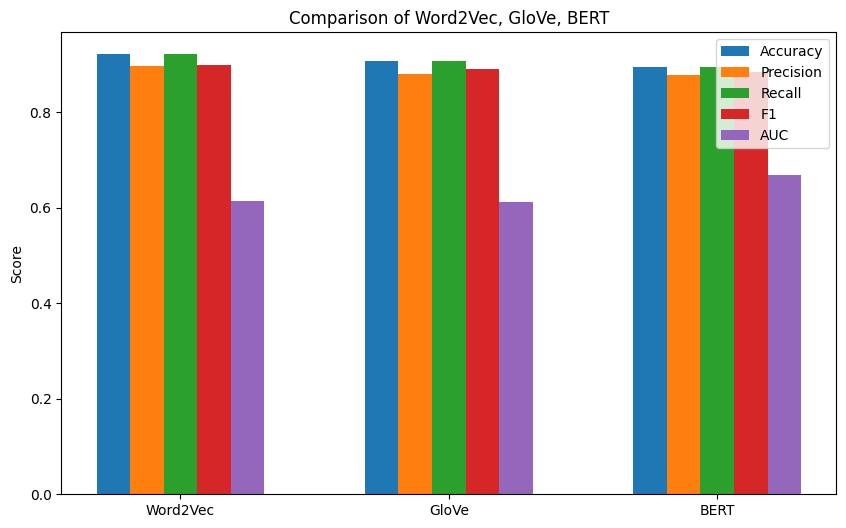

In [ ]:
# Cell: Compare Word2Vec, GloVe, BERT Performance on Sentiment Classification

def word_embedding_plot():
    # Get current active SparkSession (avoid creating duplicate)
    spark = SparkSession.getActiveSession()
    if spark is None:
        spark = SparkSession.builder.appName("ModelComparison").getOrCreate()
    print(f"Using SparkSession: {spark}")

    # =================== 1. Define Model Paths (modify according to actual save locations) ===================
    models_config = {
        "Word2Vec": {
            "train": "output/word2vec_train.parquet",
            "test": "output/word2vec_test.parquet",
        },
        "GloVe": {
            "train": "output/glove_train.parquet",
            "test": "output/glove_test.parquet",
        },
        "BERT": {"train": "output/bert_train.parquet", "test": "output/bert_test.parquet"},
    }


    # =================== 2. Evaluation Function ===================
    def evaluate_model(train_df, test_df, model_name, feature_col="features"):
        lr = LogisticRegression(featuresCol=feature_col, labelCol="Sentiment", maxIter=10)
        model = lr.fit(train_df)
        predictions = model.transform(test_df)

        acc = MulticlassClassificationEvaluator(
            labelCol="Sentiment", predictionCol="prediction", metricName="accuracy"
        ).evaluate(predictions)
        pre = MulticlassClassificationEvaluator(
            labelCol="Sentiment", predictionCol="prediction", metricName="weightedPrecision"
        ).evaluate(predictions)
        rec = MulticlassClassificationEvaluator(
            labelCol="Sentiment", predictionCol="prediction", metricName="weightedRecall"
        ).evaluate(predictions)
        f1 = MulticlassClassificationEvaluator(
            labelCol="Sentiment", predictionCol="prediction", metricName="f1"
        ).evaluate(predictions)
        auc = BinaryClassificationEvaluator(
            labelCol="Sentiment", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
        ).evaluate(predictions)

        return {
            "model": model_name,
            "accuracy": acc,
            "precision": pre,
            "recall": rec,
            "f1": f1,
            "auc": auc,
        }


    # =================== 3. Loop Evaluation ===================
    results = []
    visual_assets_data["embeddingModels"] = [
        {
            "model": "Logistic Regression (Baseline)",
            "accuracy": visual_assets_data["classicModels"][0]["accuracy"],
            "f1": visual_assets_data["classicModels"][0]["f1"],
            "precision": visual_assets_data["classicModels"][0]["precision"],
            "recall": visual_assets_data["classicModels"][0]["recall"],
            "auc": None,
            "source": "classicModels baseline"
        }
    ]

    for name, paths in models_config.items():
        print(f"Loading {name} vectors...")
        train_path = paths["train"]
        test_path = paths["test"]

        # Check if files exist
        if not os.path.exists(train_path) or not os.path.exists(test_path):
            print(f"  {name} files do not exist, skipping.")
            continue

        try:
            train_df = spark.read.parquet(train_path)
            test_df = spark.read.parquet(test_path)
            train_count = train_df.count()
            test_count = test_df.count()
            print(f"  Training set: {train_count}, Test set: {test_count}")

            metrics = evaluate_model(train_df, test_df, name)
            results.append(metrics)
            metrics1 = {k: round(v, 4) if isinstance(v, float) else v for k, v in metrics.items()}
            metrics1["source"] = "word_embedding.ipynb output"
            visual_assets_data["embeddingModels"].append(metrics1)
            print(
                f"  {name} - Acc: {metrics['accuracy']:.4f}, Pre: {metrics['precision']:.4f}, Rec: {metrics['recall']:.4f}, F1: {metrics['f1']:.4f}, AUC: {metrics['auc']:.4f}"
            )
        except Exception as e:
            print(f"  {name} processing failed: {e}")

    # =================== 4. Output Comparison Results ===================
    print("\n========== Final Comparison Results ==========")
    if results:

        pd_results = pd.DataFrame(results)
        print(pd_results.to_string(index=False))

        # Plot bar chart
        try:
            x = np.arange(len(results))
            width = 0.25
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.bar(x - width, [r["accuracy"] for r in results], width / 2, label="Accuracy")
            ax.bar(
                x - width / 2,
                [r["precision"] for r in results],
                width / 2,
                label="Precision",
            )
            ax.bar(x, [r["recall"] for r in results], width / 2, label="Recall")
            ax.bar(x + width / 2, [r["f1"] for r in results], width / 2, label="F1")
            ax.bar(x + width, [r["auc"] for r in results], width / 2, label="AUC")
            ax.set_xticks(x)
            ax.set_xticklabels([r["model"] for r in results])
            ax.set_ylabel("Score")
            ax.set_title("Comparison of Word2Vec, GloVe, BERT")
            ax.legend()
            plt.show()
        except ImportError:
            print("matplotlib not installed, skipping plot.")
    else:
        print("No models successfully loaded, please check file paths.")

    # Note: Do not stop SparkSession
    spark.stop()

word_embedding_plot()

In [ ]:



def inno():
    # =========================
    # Create Spark Session
    # =========================
    spark = SparkSession.builder \
        .appName("CDS527_Innovation_Methods_Aligned_With_Baseline") \
        .getOrCreate()

    spark.sparkContext.setLogLevel("ERROR")
    spark.conf.set("spark.sql.shuffle.partitions", "8")

    SEED = 42

    # =========================
    # Helper Functions
    # =========================
    def print_section_title(title):
        print("\n" + "=" * 80)
        print(title)
        print("=" * 80)

    def extract_predictions_from_spark(pred_df, label_col="label", pred_col="prediction"):
        pdf = pred_df.select(label_col, pred_col).toPandas()
        y_true = pdf[label_col].astype(int).values
        y_pred = pdf[pred_col].astype(int).values
        return y_true, y_pred

    def evaluate_and_print(method_name, y_true, y_pred):
        acc = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
        recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
        f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

        print_section_title(method_name)
        print("Test Accuracy:", round(acc, 4))
        print("Test Precision:", round(precision, 4))
        print("Test Recall:", round(recall, 4))
        print("Test F1:", round(f1, 4))
        print("Confusion Matrix:")
        print(cm)

    def get_metrics_dict(method_name, y_true, y_pred):
        acc = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
        recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
        f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

        return {
            "Method": method_name,
            "Accuracy": round(acc, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1": round(f1, 4),
            "TN": int(cm[0, 0]),
            "FP": int(cm[0, 1]),
            "FN": int(cm[1, 0]),
            "TP": int(cm[1, 1])
        }

    def get_pos_prob(v):
        return float(v[1])

    get_pos_prob_udf = udf(get_pos_prob, DoubleType())

    def raw_to_prob(raw_vec):
        margin = float(raw_vec[1])
        return 1.0 / (1.0 + math.exp(-margin))

    raw_to_prob_udf = udf(raw_to_prob, DoubleType())

    prob_to_pred_udf = udf(lambda p: 1 if p >= 0.5 else 0, IntegerType())
    array_to_vector_udf = udf(lambda arr: Vectors.dense(arr), VectorUDT())

    # =========================
    # 1. Load fixed split files
    #    Expected columns: Review, Rating, Sentiment
    # =========================
    train_path = "train_fixed_split.csv"
    test_path = "test_fixed_split.csv"

    raw_train_df = spark.read.csv(train_path, header=True, inferSchema=True)
    raw_test_df = spark.read.csv(test_path, header=True, inferSchema=True)

    print_section_title("Loaded fixed split files")
    print("Train size (raw):", raw_train_df.count())
    print("Test size (raw):", raw_test_df.count())

    print("\nTrain schema:")
    raw_train_df.printSchema()

    print("\nSample train rows:")
    raw_train_df.show(5, truncate=False)

    # =========================
    # 2. Align columns with baseline format
    #    Review -> text
    #    Sentiment -> label
    #    positive = 0, negative = 1
    # =========================
    train_df = raw_train_df.select(
        col("Review").cast("string").alias("text"),
        col("Rating"),
        when(lower(trim(col("Sentiment"))) == "positive", 0.0)
            .when(lower(trim(col("Sentiment"))) == "negative", 1.0)
            .otherwise(None)
            .alias("label")
    )

    test_df = raw_test_df.select(
        col("Review").cast("string").alias("text"),
        col("Rating"),
        when(lower(trim(col("Sentiment"))) == "positive", 0.0)
            .when(lower(trim(col("Sentiment"))) == "negative", 1.0)
            .otherwise(None)
            .alias("label")
    )

    train_df = train_df.dropna(subset=["text", "label"])
    test_df = test_df.dropna(subset=["text", "label"])

    print_section_title("After column alignment")
    print("Train size (clean):", train_df.count())
    print("Test size (clean):", test_df.count())

    print("\nTrain label distribution:")
    train_df.groupBy("label").count().show()

    print("Test label distribution:")
    test_df.groupBy("label").count().show()

    # =========================
    # 3. Build baseline-style TF-IDF features
    # =========================
    regex_tokenizer = RegexTokenizer(
        inputCol="text",
        outputCol="tokens",
        pattern="\\W+",
        toLowercase=True
    )

    stopword_remover = StopWordsRemover(
        inputCol="tokens",
        outputCol="filtered_tokens"
    )

    vectorizer = CountVectorizer(
        inputCol="filtered_tokens",
        outputCol="raw_features",
        vocabSize=10000,
        minDF=2.0
    )

    idf = IDF(
        inputCol="raw_features",
        outputCol="features"
    )

    feature_pipeline = Pipeline(stages=[
        regex_tokenizer,
        stopword_remover,
        vectorizer,
        idf
    ])

    feature_model = feature_pipeline.fit(train_df)

    train_feat = feature_model.transform(train_df).select("text", "label", "features")
    test_feat = feature_model.transform(test_df).select("text", "label", "features")

    print_section_title("Feature engineering completed")
    print("Train feature count:", train_feat.count())
    print("Test feature count:", test_feat.count())

    # =========================
    # 4. Baseline placeholder
    # =========================
    results = []

    official_baseline = {
        "Method": "Official_Baseline",
        "Accuracy": 0.7329,
        "Precision": 0.8856,
        "Recall": 0.7329,
        "F1": 0.7907,
        "TN": 12,
        "FP": 11,
        "FN": 67,
        "TP": 202
    }

    results.append(official_baseline)

    print_section_title("Official Baseline (Placeholder)")
    print("Test Accuracy:", official_baseline["Accuracy"])
    print("Test Precision:", official_baseline["Precision"])
    print("Test Recall:", official_baseline["Recall"])
    print("Test F1:", official_baseline["F1"])

    # 正方形混淆矩阵
    print("Confusion Matrix (square):")
    print("          Predicted")
    print("          positive  negative")
    print(f"Actual positive     {official_baseline['TP']}       {official_baseline['FN']}")
    print(f"      negative     {official_baseline['FP']}       {official_baseline['TN']}")

    # 一行数字形式
    print(f"Confusion Matrix (row): TP={official_baseline['TP']}, FN={official_baseline['FN']}, FP={official_baseline['FP']}, TN={official_baseline['TN']}")

    # =========================
    # Innovation 1: SMOTE + Logistic Regression
    # =========================
    print_section_title("Innovation 1 - SMOTE + Logistic Regression")

    train_pd = train_feat.select("label", "features").toPandas()
    X_train_np = np.array([x.toArray() for x in train_pd["features"]])
    y_train_np = train_pd["label"].astype(int).values

    print("Class distribution before SMOTE:")
    unique, counts = np.unique(y_train_np, return_counts=True)
    print(dict(zip(unique, counts)))

    smote = SMOTE(random_state=SEED)
    X_resampled, y_resampled = smote.fit_resample(X_train_np, y_train_np)

    print("Class distribution after SMOTE:")
    unique_res, counts_res = np.unique(y_resampled, return_counts=True)
    print(dict(zip(unique_res, counts_res)))

    smote_pd = pd.DataFrame({
        "label": y_resampled.tolist(),
        "features_array": [x.tolist() for x in X_resampled]
    })

    smote_spark = spark.createDataFrame(smote_pd)

    smote_train_feat = smote_spark.withColumn(
        "features", array_to_vector_udf(col("features_array"))
    ).select(
        col("label").cast("double"),
        col("features")
    )

    lr_smote = LogisticRegression(
        featuresCol="features",
        labelCol="label",
        predictionCol="prediction",
        probabilityCol="probability",
        maxIter=100,
        regParam=0.0,
        elasticNetParam=0.0
    )

    smote_model = lr_smote.fit(smote_train_feat)
    smote_pred = smote_model.transform(test_feat)

    y_true_smote, y_pred_smote = extract_predictions_from_spark(smote_pred)
    evaluate_and_print("Innovation 1 - SMOTE + Logistic Regression", y_true_smote, y_pred_smote)
    results.append(get_metrics_dict("Innovation1_SMOTE_LR", y_true_smote, y_pred_smote))

    # =========================
    # Innovation 2: Weighted Ensemble
    # =========================
    print_section_title("Innovation 2 - Weighted Ensemble (RF + GBT + LR)")

    rf = RandomForestClassifier(
        featuresCol="features",
        labelCol="label",
        predictionCol="rf_prediction",
        probabilityCol="rf_probability",
        numTrees=120,
        maxDepth=8,
        seed=SEED
    )

    gbt = GBTClassifier(
        featuresCol="features",
        labelCol="label",
        predictionCol="gbt_prediction",
        maxIter=60,
        maxDepth=5,
        seed=SEED
    )

    lr = LogisticRegression(
        featuresCol="features",
        labelCol="label",
        predictionCol="lr_prediction",
        probabilityCol="lr_probability",
        maxIter=100,
        regParam=0.0,
        elasticNetParam=0.0
    )

    rf_model = rf.fit(train_feat)
    gbt_model = gbt.fit(train_feat)
    lr_model = lr.fit(train_feat)

    ensemble_df = test_feat

    ensemble_df = rf_model.transform(ensemble_df)
    ensemble_df = ensemble_df.withColumnRenamed("rawPrediction", "rf_rawPrediction")

    ensemble_df = gbt_model.transform(ensemble_df)
    ensemble_df = ensemble_df.withColumnRenamed("rawPrediction", "gbt_rawPrediction")

    ensemble_df = lr_model.transform(ensemble_df)
    ensemble_df = ensemble_df.withColumnRenamed("rawPrediction", "lr_rawPrediction")

    ensemble_df = ensemble_df \
        .withColumn("rf_pos_prob", get_pos_prob_udf(col("rf_probability"))) \
        .withColumn("lr_pos_prob", get_pos_prob_udf(col("lr_probability"))) \
        .withColumn("gbt_pos_prob", raw_to_prob_udf(col("gbt_rawPrediction")))

    w_rf = 0.35
    w_gbt = 0.40
    w_lr = 0.25

    ensemble_df = ensemble_df.withColumn(
        "ensemble_prob",
        w_rf * col("rf_pos_prob") + w_gbt * col("gbt_pos_prob") + w_lr * col("lr_pos_prob")
    )

    ensemble_df = ensemble_df.withColumn(
        "prediction",
        prob_to_pred_udf(col("ensemble_prob"))
    )

    y_true_ens, y_pred_ens = extract_predictions_from_spark(ensemble_df)
    evaluate_and_print("Innovation 2 - Weighted Ensemble (RF + GBT + LR)", y_true_ens, y_pred_ens)
    results.append(get_metrics_dict("Innovation2_Weighted_Ensemble", y_true_ens, y_pred_ens))

    # =========================
    # Innovation 3: Threshold Moving
    # =========================
    print_section_title("Innovation 3 - Threshold Moving")

    train_sub, valid_sub = train_feat.randomSplit([0.8, 0.2], seed=SEED)

    lr_threshold = LogisticRegression(
        featuresCol="features",
        labelCol="label",
        predictionCol="prediction",
        probabilityCol="probability",
        maxIter=100,
        regParam=0.0,
        elasticNetParam=0.0
    )

    threshold_model = lr_threshold.fit(train_sub)
    valid_pred = threshold_model.transform(valid_sub)

    valid_pdf = valid_pred.select("label", "probability").toPandas()
    valid_pdf["pos_prob"] = valid_pdf["probability"].apply(lambda v: float(v[1]))

    best_threshold = 0.50
    best_f1 = -1

    for threshold in np.arange(0.30, 0.71, 0.02):
        y_valid_true = valid_pdf["label"].astype(int).values
        y_valid_pred = (valid_pdf["pos_prob"] >= threshold).astype(int)
        current_f1 = f1_score(y_valid_true, y_valid_pred, average="weighted", zero_division=0)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = threshold

    print(f"Best threshold found on validation set: {best_threshold:.2f}")
    print(f"Best validation F1: {best_f1:.4f}")

    final_threshold_model = lr_threshold.fit(train_feat)
    test_threshold_pred = final_threshold_model.transform(test_feat)

    test_threshold_pdf = test_threshold_pred.select("label", "probability").toPandas()
    test_threshold_pdf["pos_prob"] = test_threshold_pdf["probability"].apply(lambda v: float(v[1]))
    test_threshold_pdf["prediction"] = (test_threshold_pdf["pos_prob"] >= best_threshold).astype(int)

    y_true_threshold = test_threshold_pdf["label"].astype(int).values
    y_pred_threshold = test_threshold_pdf["prediction"].astype(int).values

    evaluate_and_print(
        f"Innovation 3 - Threshold Moving (threshold={best_threshold:.2f})",
        y_true_threshold,
        y_pred_threshold
    )

    results.append(get_metrics_dict("Innovation3_Threshold_Moving", y_true_threshold, y_pred_threshold))

    # =========================
    # Innovation 4: Confidence-Based Pseudo-Labeling
    # =========================
    print_section_title("Innovation 4 - Confidence-Based Pseudo-Labeling")

    labeled_df, pseudo_pool_df = train_df.randomSplit([0.8, 0.2], seed=SEED)

    print("labeled_df size:", labeled_df.count())
    print("pseudo_pool_df size:", pseudo_pool_df.count())
    print("test_df size:", test_df.count())

    pseudo_pipeline = Pipeline(stages=[
        RegexTokenizer(inputCol="text", outputCol="tokens", pattern="\\W+", toLowercase=True),
        StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens"),
        CountVectorizer(inputCol="filtered_tokens", outputCol="raw_features", vocabSize=10000, minDF=2.0),
        IDF(inputCol="raw_features", outputCol="features")
    ])

    pseudo_feature_model = pseudo_pipeline.fit(labeled_df)

    labeled_feat = pseudo_feature_model.transform(labeled_df).select("text", "label", "features")
    pseudo_pool_feat = pseudo_feature_model.transform(pseudo_pool_df).select("text", "features")
    pseudo_test_feat = pseudo_feature_model.transform(test_df).select("label", "features")

    pseudo_lr_init = LogisticRegression(
        featuresCol="features",
        labelCol="label",
        predictionCol="prediction",
        probabilityCol="probability",
        maxIter=100,
        regParam=0.0,
        elasticNetParam=0.0
    )

    initial_model = pseudo_lr_init.fit(labeled_feat)

    pseudo_pred = initial_model.transform(pseudo_pool_feat)
    pseudo_pred = pseudo_pred.withColumn("pos_prob", get_pos_prob_udf(col("probability")))

    POS_THRESHOLD = 0.95
    NEG_THRESHOLD = 0.05

    high_conf_pos = pseudo_pred.filter(col("pos_prob") >= POS_THRESHOLD) \
        .select("text", "features") \
        .withColumn("final_label", lit(1.0))

    high_conf_neg = pseudo_pred.filter(col("pos_prob") <= NEG_THRESHOLD) \
        .select("text", "features") \
        .withColumn("final_label", lit(0.0))

    pseudo_selected = high_conf_pos.unionByName(high_conf_neg)

    print("Selected pseudo-labeled samples:", pseudo_selected.count())
    print("Pseudo positive count:", high_conf_pos.count())
    print("Pseudo negative count:", high_conf_neg.count())

    original_labeled_train = labeled_feat.select(
        "text",
        "features",
        col("label").alias("final_label")
    )

    augmented_train = original_labeled_train.unionByName(pseudo_selected)

    print("Original labeled training size:", original_labeled_train.count())
    print("Augmented training size:", augmented_train.count())

    pseudo_lr = LogisticRegression(
        featuresCol="features",
        labelCol="final_label",
        predictionCol="prediction",
        probabilityCol="probability",
        maxIter=100,
        regParam=0.0,
        elasticNetParam=0.0
    )

    pseudo_model = pseudo_lr.fit(augmented_train)

    test_eval_df = pseudo_test_feat.select(
        "features",
        col("label").alias("final_label")
    )

    test_pred = pseudo_model.transform(test_eval_df).select("final_label", "prediction")

    rows = test_pred.collect()
    y_true_pseudo = [int(row["final_label"]) for row in rows]
    y_pred_pseudo = [int(row["prediction"]) for row in rows]

    evaluate_and_print(
        f"Innovation 4 - Confidence-Based Pseudo-Labeling ({POS_THRESHOLD:.2f}/{NEG_THRESHOLD:.2f})",
        y_true_pseudo,
        y_pred_pseudo
    )

    results.append(
        get_metrics_dict(
            "Innovation4_PseudoLabeling",
            y_true_pseudo,
            y_pred_pseudo
        )
    )

    # =========================
    # Final Comparison Table
    # =========================
    print_section_title("Final Comparison Table: Baseline vs Innovation Methods")

    results_df = pd.DataFrame(results)
    results_df = results_df.drop_duplicates(subset=["Method"]).reset_index(drop=True)
    results_df = results_df.sort_values(by=["F1", "Accuracy"], ascending=False).reset_index(drop=True)

    print(results_df)

    results_df.to_csv("innovation_vs_baseline_results.csv", index=False, encoding="utf-8-sig")
    print("\nSaved file: innovation_vs_baseline_results.csv")

    try:
        from IPython.display import display
        display(results_df)
    except:
        pass

    # =========================
    # Short Summary
    # =========================
    print_section_title("Short Summary")

    best_method = results_df.iloc[0]["Method"]
    best_f1 = results_df.iloc[0]["F1"]
    best_acc = results_df.iloc[0]["Accuracy"]

    print(f"The best-performing method in this comparison is: {best_method}")
    print(f"Best F1: {best_f1}")
    print(f"Best Accuracy: {best_acc}")

inno()


Loaded fixed split files
Train size (raw): 1199
Test size (raw): 292

Train schema:
root
 |-- Review: string (nullable = true)
 |-- Rating: double (nullable = true)
 |-- Sentiment: string (nullable = true)


Sample train rows:
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

,Method,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
0,Innovation2_Weighted_Ensemble,0.9007,0.8597,0.9007,0.8780,262,7,22,1
1,Innovation1_SMOTE_LR,0.8767,0.8716,0.8767,0.8741,252,17,19,4
2,Official_Baseline,0.7329,0.8856,0.7329,0.7907,12,11,67,202
3,Innovation3_Threshold_Moving,0.7226,0.8891,0.7226,0.7839,198,71,10,13
4,Innovation4_PseudoLabeling,0.6986,0.8773,0.6986,0.7660,193,76,12,11



Short Summary
The best-performing method in this comparison is: Innovation2_Weighted_Ensemble
Best F1: 0.878
Best Accuracy: 0.9007


In [ ]:


visual_assets_data["notes"] = {
    "classic": "Classic ML metrics were recomputed from the current Spark pipeline, with the baseline overridden to match the PPT standard.",
    "embedding": "Embedding metrics were restored from the saved notebook outputs.",
    "reproducibility": "Run `python visuals/render_all_visuals.py` after data updates to regenerate every single-chart asset.",
    "embeddingLimitation": "Word2Vec / GloVe / BERT Precision, Recall and confusion matrices are not present in the saved local outputs. Ask the teammate who ran word_embedding.ipynb to export the full classification reports if you need those figures on the final slide.",
}
OUTPUT_DIR = "./split_outputs"
# DATA_PATH = OUTPUT_DIR / "visual_assets_data.json"

THEME = {
    "bg": "#3A295B",
    "text": "#FFFFFF",
    "cyan": "#65F0F9",
    "blue": "#7BA5D8",
    "deep_purple": "#4B2A8C",
    "light_purple": "#A888D5",
    "outline": "#8B5CF6",
    "panel": "rgba(84, 56, 134, 0.42)",
    "border": "rgba(255, 255, 255, 0.16)",
}



def load_review_frames() -> tuple[pd.DataFrame, pd.DataFrame]:
    train_path = "./train_fixed_split.csv"
    test_path = "./test_fixed_split.csv"
    train_df = pd.read_csv(train_path).dropna(subset=["Review"]).copy()
    test_df = pd.read_csv(test_path).dropna(subset=["Review"]).copy()
    return train_df, test_df


def collect_keywords(texts: pd.Series, extra_stopwords: set[str]) -> list[dict]:
    base_stopwords = set(ENGLISH_STOP_WORDS) | {
        "album",
        "albums",
        "also",
        "dark",
        "dont",
        "floyd",
        "get",
        "going",
        "good",
        "great",
        "just",
        "like",
        "made",
        "make",
        "moon",
        "movie",
        "movies",
        "music",
        "netflix",
        "one",
        "pink",
        "que",
        "really",
        "series",
        "show",
        "shows",
        "song",
        "songs",
        "story",
        "take",
        "thing",
        "time",
        "watch",
        "watched",
        "watching",
        "will",
    }
    stopwords = base_stopwords | extra_stopwords
    counter: Counter[str] = Counter()
    for text in texts.astype(str):
        tokens = re.findall(r"[a-zA-Z]{3,}", text.lower())
        counter.update(token for token in tokens if token not in stopwords)
    return [{"word": word, "value": value} for word, value in counter.most_common(120)]


def build_visual_data() -> dict:
    return visual_assets_data


def load_or_build_visual_data() -> dict:
    return visual_assets_data


def base_page(title: str, body: str, note: str = "") -> str:
    note_html = f"<div class='note-box'>{note}</div>" if note else ""
    return f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>{title}</title>
  <style>
    :root {{
      --bg: {THEME['bg']};
      --text: {THEME['text']};
      --cyan: {THEME['cyan']};
      --blue: {THEME['blue']};
      --deep-purple: {THEME['deep_purple']};
      --light-purple: {THEME['light_purple']};
      --outline: {THEME['outline']};
      --panel: {THEME['panel']};
      --border: {THEME['border']};
    }}
    * {{ box-sizing: border-box; }}
    body {{
      margin: 0;
      min-height: 100vh;
      color: var(--text);
      font-family: "Segoe UI", "PingFang SC", "Microsoft YaHei", sans-serif;
      background:
        radial-gradient(circle at 12% 16%, rgba(101,240,249,0.16), transparent 18%),
        radial-gradient(circle at 84% 12%, rgba(168,136,213,0.20), transparent 20%),
        linear-gradient(135deg, #2E2049 0%, #3A295B 48%, #4B2A8C 100%);
      padding: 24px;
    }}
    .card {{
      max-width: 1200px;
      margin: 0 auto;
      border-radius: 28px;
      border: 1px solid var(--border);
      background: linear-gradient(180deg, rgba(82,55,132,0.70), rgba(46,31,79,0.95));
      box-shadow: 0 24px 60px rgba(0,0,0,0.35);
      overflow: hidden;
    }}
    .body {{ padding: 26px; }}
    h1 {{
      margin: 0 0 18px;
      font-size: 24px;
      display: flex;
      gap: 10px;
      align-items: center;
    }}
    .hex {{
      width: 14px;
      height: 14px;
      display: inline-block;
      background: var(--cyan);
      clip-path: polygon(25% 6%, 75% 6%, 100% 50%, 75% 94%, 25% 94%, 0 50%);
      border: 1px solid var(--outline);
    }}
    .note-box {{
      margin-top: 16px;
      padding: 14px 16px;
      border-radius: 18px;
      background: rgba(255,255,255,0.06);
      border: 1px dashed rgba(101,240,249,0.42);
      color: rgba(255,255,255,0.86);
      line-height: 1.7;
    }}
    .matrix-grid {{
      display: grid;
      grid-template-columns: repeat(2, minmax(0, 1fr));
      gap: 16px;
    }}
    .matrix-card {{
      padding: 16px;
      border-radius: 22px;
      background: rgba(255,255,255,0.05);
      border: 1px solid rgba(255,255,255,0.08);
    }}
    .matrix-title {{
      margin: 0 0 12px;
      font-size: 16px;
    }}
    .matrix {{
      display: grid;
      grid-template-columns: 74px repeat(2, 1fr);
      gap: 8px;
    }}
    .matrix-label, .matrix-cell {{
      padding: 12px 10px;
      border-radius: 14px;
      text-align: center;
      font-size: 13px;
    }}
    .matrix-label {{
      background: rgba(255,255,255,0.06);
      color: rgba(255,255,255,0.80);
    }}
    .matrix-cell {{
      font-weight: 700;
      color: white;
    }}
    .word-cols {{
      display: grid;
      grid-template-columns: repeat(2, minmax(0, 1fr));
      gap: 16px;
    }}
    .word-panel {{
      padding: 18px;
      border-radius: 24px;
      background: rgba(255,255,255,0.05);
      border: 1px solid rgba(255,255,255,0.08);
    }}
    .word-panel h2 {{
      margin: 0 0 12px;
      font-size: 18px;
    }}
    .word-cloud-svg {{
      width: 100%;
      height: 420px;
      display: block;
      border-radius: 20px;
      background:
        radial-gradient(circle at 22% 18%, rgba(101,240,249,0.10), transparent 24%),
        radial-gradient(circle at 78% 22%, rgba(168,136,213,0.16), transparent 26%),
        rgba(255,255,255,0.03);
    }}
    .cloud-word {{
      font-family: "Segoe UI", "PingFang SC", "Microsoft YaHei", sans-serif;
      text-anchor: middle;
      dominant-baseline: middle;
      stroke: rgba(40, 21, 70, 0.25);
      stroke-width: 1px;
      paint-order: stroke fill;
    }}
    @media (max-width: 900px) {{
      .matrix-grid, .word-cols {{ grid-template-columns: 1fr; }}
    }}
  </style>
</head>
<body>
  <main class="card">
    <section class="body">
      <h1><span class="hex"></span>{title}</h1>
      {body}
      {note_html}
    </section>
  </main>
</body>
</html>"""


def metric_chart_svg(items: list[dict], metric_defs: list[dict]) -> str:
    width = 1100
    height = 560
    margin = {"top": 36, "right": 24, "bottom": 120, "left": 72}
    inner_width = width - margin["left"] - margin["right"]
    inner_height = height - margin["top"] - margin["bottom"]
    group_step = inner_width / max(len(items), 1)
    group_width = min(220, group_step * 0.82)
    gap = 10
    bar_width = (group_width - gap * (len(metric_defs) - 1)) / len(metric_defs)

    def scale_y(value: float) -> float:
        return margin["top"] + inner_height - value * inner_height

    grid = []
    for i in range(6):
        value = i / 5
        y = scale_y(value)
        grid.append(
            f"<line x1='{margin['left']}' y1='{y}' x2='{width - margin['right']}' y2='{y}' stroke='rgba(255,255,255,0.16)' stroke-dasharray='4 6'></line>"
            f"<text x='{margin['left'] - 12}' y='{y + 4}' fill='rgba(255,255,255,0.86)' font-size='12' text-anchor='end'>{value:.2f}</text>"
        )

    bars = []
    for idx, item in enumerate(items):
        start_x = margin["left"] + group_step * idx + (group_step - group_width) / 2
        for metric_idx, metric in enumerate(metric_defs):
            value = item.get(metric["key"])
            x = start_x + metric_idx * (bar_width + gap)
            if value is None:
                bars.append(
                    f"<rect x='{x}' y='{scale_y(0)}' width='{bar_width}' height='2' rx='2' fill='rgba(255,255,255,0.26)'></rect>"
                    f"<text x='{x + bar_width/2}' y='{scale_y(0) - 8}' fill='rgba(255,255,255,0.82)' font-size='12' text-anchor='middle'>N/A</text>"
                    f"<text x='{x + bar_width/2}' y='{height - 28}' fill='rgba(255,255,255,0.86)' font-size='13' text-anchor='middle'>{metric['short']}</text>"
                )
                continue
            y = scale_y(value)
            h = margin["top"] + inner_height - y
            bars.append(
                f"<rect x='{x}' y='{y}' width='{bar_width}' height='{h}' rx='12' fill='{metric['color']}'></rect>"
                f"<text x='{x + bar_width/2}' y='{y - 10}' fill='white' font-size='12' font-weight='700' text-anchor='middle'>{value:.4f}</text>"
                f"<text x='{x + bar_width/2}' y='{height - 28}' fill='rgba(255,255,255,0.86)' font-size='13' text-anchor='middle'>{metric['short']}</text>"
            )
        bars.append(
            f"<text x='{start_x + group_width/2}' y='{height - 62}' fill='rgba(255,255,255,0.94)' font-size='15' text-anchor='middle'>{item['model'].replace(' (Baseline)', '')}</text>"
        )

    return (
        f"<svg viewBox='0 0 {width} {height}' width='100%' height='auto'>"
        + "".join(grid)
        + f"<line x1='{margin['left']}' y1='{margin['top'] + inner_height}' x2='{width - margin['right']}' y2='{margin['top'] + inner_height}' stroke='rgba(255,255,255,0.28)'></line>"
        + "".join(bars)
        + "</svg>"
    )


def matrix_heat_color(value: int, max_value: int) -> str:
    ratio = 0 if max_value == 0 else value / max_value
    r = round(75 + ratio * 93)
    g = round(42 + ratio * 198)
    b = round(140 + ratio * 109)
    return f"rgb({r},{g},{b})"


def word_cloud_svg(items: list[dict], colors: list[str]) -> str:
    words = sorted(items, key=lambda item: item["value"], reverse=True)[:90]
    width = 540
    height = 420
    center_x = width / 2
    center_y = height / 2
    min_value = words[-1]["value"]
    max_value = words[0]["value"]
    placed: list[dict] = []
    svg_parts = [f"<svg class='word-cloud-svg' viewBox='0 0 {width} {height}'>"]

    def collides(box: dict) -> bool:
        for item in placed:
            if not (
                box["x2"] < item["x1"]
                or box["x1"] > item["x2"]
                or box["y2"] < item["y1"]
                or box["y1"] > item["y2"]
            ):
                return True
        return False

    for index, item in enumerate(words):
        ratio = (
            1
            if max_value == min_value
            else (item["value"] - min_value) / (max_value - min_value)
        )
        font_size = 12 + pow(ratio, 0.72) * 110
        text_width = max(len(item["word"]) * font_size * 0.48, font_size * 1.2)
        text_height = font_size * 0.74
        rotate = 0 if ratio > 0.8 else (-90 if index % 11 == 0 else 0)
        box_width = text_width if rotate == 0 else text_height
        box_height = text_height if rotate == 0 else text_width
        angle = index * 0.92
        radius = 0.0
        chosen = None
        for _ in range(900):
            x = center_x + radius * __import__("math").cos(angle)
            y = center_y + radius * 0.72 * __import__("math").sin(angle)
            candidate = {
                "x": x,
                "y": y,
                "x1": x - box_width / 2 - 8,
                "x2": x + box_width / 2 + 8,
                "y1": y - box_height / 2 - 6,
                "y2": y + box_height / 2 + 6,
            }
            fits = (
                candidate["x1"] >= 8
                and candidate["x2"] <= width - 8
                and candidate["y1"] >= 8
                and candidate["y2"] <= height - 8
            )
            if fits and not collides(candidate):
                chosen = candidate
                placed.append(candidate)
                break
            angle += 0.33
            radius += 0.95
        if not chosen:
            continue
        fill = colors[index % len(colors)]
        safe_word = (
            item["word"].replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")
        )
        svg_parts.append(
            f"<text class='cloud-word' x='{chosen['x']:.1f}' y='{chosen['y']:.1f}' font-size='{font_size:.1f}' font-weight='700' fill='{fill}' transform='rotate({rotate} {chosen['x']:.1f} {chosen['y']:.1f})'>{safe_word}</text>"
        )
    svg_parts.append("</svg>")
    return "".join(svg_parts)


def render_bar_chart_ml() -> None:
    data = load_or_build_visual_data()
    parts = ["<div class='matrix-grid'>"]
    for model, matrix in data["classicConfusionMatrices"].items():
        max_value = max(value for row in matrix for value in row)
        tn, fp = matrix[0]
        fn, tp = matrix[1]
        parts.append(
            f"""
            <article class="matrix-card">
              <h2 class="matrix-title">{model}</h2>
              <div class="matrix">
                <div class="matrix-label"></div>
                <div class="matrix-label">Pred Neg</div>
                <div class="matrix-label">Pred Pos</div>
                <div class="matrix-label">True Neg</div>
                <div class="matrix-cell" style="background:{matrix_heat_color(tn, max_value)}">{tn}</div>
                <div class="matrix-cell" style="background:{matrix_heat_color(fp, max_value)}">{fp}</div>
                <div class="matrix-label">True Pos</div>
                <div class="matrix-cell" style="background:{matrix_heat_color(fn, max_value)}">{fn}</div>
                <div class="matrix-cell" style="background:{matrix_heat_color(tp, max_value)}">{tp}</div>
              </div>
            </article>
            """
        )
    parts.append("</div>")
    html = base_page("Confusion Matrix ML", "".join(parts), data["notes"]["classic"])
    with open("./confusion_matrix_ml.html", "w", encoding="utf-8") as f:
        f.write(html)


def render_bar_chart_word_embed() -> None:
    data = load_or_build_visual_data()
    metric_defs = [
        {"key": "accuracy", "short": "Acc", "color": THEME["cyan"]},
        {"key": "precision", "short": "Pre", "color": THEME["blue"]},
        {"key": "recall", "short": "Rec", "color": THEME["deep_purple"]},
        {"key": "f1", "short": "F1", "color": THEME["light_purple"]},
    ]
    html = base_page(
        "Bar Chart Word Embed",
        metric_chart_svg(data["embeddingModels"], metric_defs),
        data["notes"]["embedding"],
    )
    with open("./bar_chart_word_embed.html", "w", encoding="utf-8") as f:
        f.write(html)


def render_confusion_matrix_ml() -> None:
    data = load_or_build_visual_data()
    metric_defs = [
        {"key": "accuracy", "short": "Acc", "color": THEME["cyan"]},
        {"key": "precision", "short": "Pre", "color": THEME["blue"]},
        {"key": "recall", "short": "Rec", "color": THEME["deep_purple"]},
        {"key": "f1", "short": "F1", "color": THEME["light_purple"]},
    ]
    html = base_page(
        "Bar Chart ML",
        metric_chart_svg(data["classicModels"], metric_defs),
        data["notes"]["classic"],
    )
    with open("./bar_chart_ml.html", "w", encoding="utf-8") as f:
        f.write(html)


def render_pie_distribution() -> None:
    data = load_or_build_visual_data()
    items = data["classDistribution"][0]
    total = sum(item["count"] for item in items)
    positive = next(item["count"] for item in items if item["label"] == "Positive")
    positive_ratio = positive / total if total else 0
    negative = total - positive
    body = f"""
    <div style="display:grid;grid-template-columns:300px 1fr;gap:24px;align-items:center;">
      <div style="width:260px;height:260px;border-radius:50%;margin:0 auto;position:relative;background:conic-gradient({THEME['cyan']} 0 {(positive_ratio * 360):.1f}deg, {THEME['light_purple']} {(positive_ratio * 360):.1f}deg 360deg);box-shadow:inset 0 0 0 1px rgba(255,255,255,0.08);">
        <div style="position:absolute;inset:40px;border-radius:50%;background:rgba(44,28,74,0.96);border:1px solid rgba(255,255,255,0.1);display:flex;align-items:center;justify-content:center;flex-direction:column;">
          <div style="font-size:36px;font-weight:800;">{positive_ratio * 100:.1f}%</div>
          <div style="font-size:13px;letter-spacing:0.16em;text-transform:uppercase;color:rgba(255,255,255,0.75);">Positive share</div>
        </div>
      </div>
      <div>
        <div style="display:grid;gap:14px;">
          <div style="display:flex;justify-content:space-between;padding:16px 18px;border-radius:18px;background:rgba(255,255,255,0.06);">
            <div><span style="display:inline-block;width:12px;height:12px;border-radius:50%;background:{THEME['light_purple']};margin-right:10px;"></span>Negative</div>
            <strong>{negative}</strong>
          </div>
          <div style="display:flex;justify-content:space-between;padding:16px 18px;border-radius:18px;background:rgba(255,255,255,0.06);">
            <div><span style="display:inline-block;width:12px;height:12px;border-radius:50%;background:{THEME['cyan']};margin-right:10px;"></span>Positive</div>
            <strong>{positive}</strong>
          </div>
          <div style="padding:16px 18px;border-radius:18px;background:rgba(255,255,255,0.06);line-height:1.7;color:rgba(255,255,255,0.84);">
            Train / Test: <strong>{data['datasetStats']['trainSamples']} / {data['datasetStats']['testSamples']}</strong><br>
            Mean word count: <strong>{data['datasetStats']['meanWordCount']:.2f}</strong><br>
            Median word count: <strong>{data['datasetStats']['medianWordCount']:.2f}</strong>
          </div>
        </div>
      </div>
    </div>
    """
    html = base_page("Pie Chart Distribution", body, data["notes"]["reproducibility"])
    with open("./pie_chart_distribution.html", "w", encoding="utf-8") as f:
        f.write(html)


def render_word_cloud_reviews() -> None:
    data = load_or_build_visual_data()
    body = f"""
    <div class="word-cols">
      <section class="word-panel">
        <h2 style="color:#65F0F9">Positive Reviews</h2>
        {word_cloud_svg(data["positiveKeywords"][0], ["#65F0F9", "#FFFFFF", "#7BA5D8", "#D8F9FF", "#A888D5"])}
      </section>
      <section class="word-panel">
        <h2 style="color:#A888D5">Negative Reviews</h2>
        {word_cloud_svg(data["negativeKeywords"][0], ["#A888D5", "#FFFFFF", "#65F0F9", "#7BA5D8", "#D9C6FF"])}
      </section>
    </div>
    """
    html = base_page("Word Cloud Reviews", body)
    with open("./word_cloud_reviews.html", "w", encoding="utf-8") as f:
        f.write(html)


def render_all_visuals() -> None:
    data = build_visual_data()
    render_bar_chart_ml()
    render_bar_chart_word_embed()
    render_confusion_matrix_ml()
    render_pie_distribution()
    render_word_cloud_reviews()
    print("Generated split visual assets in visuals/split_outputs")


if __name__ == "__main__":
    train_df, test_df = load_review_frames()
    visual_assets_data["positiveKeywords"] = (
        collect_keywords(train_df.loc[train_df["Sentiment"] == "positive", "Review"], {"positive"}),
    )
    visual_assets_data["negativeKeywords"] = (
        collect_keywords(train_df.loc[train_df["Sentiment"] == "negative", "Review"], {"negative"}),
    )
    render_all_visuals()


Generated split visual assets in visuals/split_outputs


In [1]:
# models.py
# Updated to handle missing 'label' columns by indexing 'Sentiment' on the fly.
# All models utilize the same weighted pipeline to ensure fair comparison.

from pyspark.sql import DataFrame
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import (
    SQLTransformer,
    RegexTokenizer,
    StopWordsRemover,
    CountVectorizer,
    IDF,
    StringIndexer,
)
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
    GBTClassifier,
)
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import classification_report

def _add_weights(train_df: DataFrame):
    """
    Computes class weights to handle imbalance (equivalent to class_weight='balanced').
    Requires a numeric 'label' column to exist.
    """
    total_count = train_df.count()
    counts = train_df.groupBy("label").count().collect()
    num_classes = len(counts)

    # Create a dictionary for mapping: {label: weight}
    weight_dict = {row['label']: total_count / (num_classes * row['count']) for row in counts}

    # Create a conditional mapping column
    mapping_expr = F.create_map([F.lit(x) for x in sum(weight_dict.items(), ())])
    return train_df.withColumn("classWeight", mapping_expr[F.col("label")])

def _build_feature_pipeline(vocab_size=10000, min_df=2.0):
    """
    Feature engineering pipeline for text:
    Text cleaning -> Tokenization -> Stopword removal -> CountVectorization -> IDF.
    """
    clean_text_sql = SQLTransformer(
        statement="""
        SELECT *, lower(regexp_replace(Review, '[^a-zA-Z\\s]', ' ')) AS clean_text FROM __THIS__
        """
    )

    tokenizer = RegexTokenizer(
        inputCol="clean_text",
        outputCol="tokens",
        pattern="\\s+"
    )

    remover = StopWordsRemover(
        inputCol="tokens",
        outputCol="filtered_tokens"
    )

    vectorizer = CountVectorizer(
        inputCol="filtered_tokens",
        outputCol="raw_features",
        vocabSize=vocab_size,
        minDF=min_df
    )

    idf = IDF(inputCol="raw_features", outputCol="features")

    return Pipeline(stages=[clean_text_sql, tokenizer, remover, vectorizer, idf])

def train_logistic_regression(train_df: DataFrame, seed=42):
    # 1. Ensure 'label' column exists for weight calculation
    label_indexer = StringIndexer(inputCol="Sentiment", outputCol="label").fit(train_df)
    indexed_df = label_indexer.transform(train_df)

    # 2. Add weights
    train_weighted = _add_weights(indexed_df)

    # 3. Build text feature model
    feat_pipeline = _build_feature_pipeline()
    feat_model = feat_pipeline.fit(train_weighted)

    # 4. Prepare training features
    train_features = feat_model.transform(train_weighted)

    lr = LogisticRegression(
        labelCol="label",
        featuresCol="features",
        weightCol="classWeight",
        maxIter=100,
        regParam=0.01,
        elasticNetParam=0,
        predictionCol="prediction",
        family="binomial"
    )

    # Return the trained classifier and a combined model for the test set
    combined_feat_model = PipelineModel(stages=[label_indexer, feat_model])
    return lr.fit(train_features), combined_feat_model

def train_decision_tree(train_df: DataFrame, max_depth=10, seed=42):
    label_indexer = StringIndexer(inputCol="Sentiment", outputCol="label").fit(train_df)
    indexed_df = label_indexer.transform(train_df)

    train_weighted = _add_weights(indexed_df)
    feat_pipeline = _build_feature_pipeline()
    feat_model = feat_pipeline.fit(train_weighted)
    train_features = feat_model.transform(train_weighted)

    dt = DecisionTreeClassifier(
        labelCol="label",
        featuresCol="features",
        weightCol="classWeight",
        maxDepth=max_depth,
        seed=seed
    )
    combined_feat_model = PipelineModel(stages=[label_indexer, feat_model])
    return dt.fit(train_features), combined_feat_model

def train_random_forest(train_df: DataFrame, num_trees=50, max_depth=10, seed=42):
    label_indexer = StringIndexer(inputCol="Sentiment", outputCol="label").fit(train_df)
    indexed_df = label_indexer.transform(train_df)

    train_weighted = _add_weights(indexed_df)
    feat_pipeline = _build_feature_pipeline()
    feat_model = feat_pipeline.fit(train_weighted)
    train_features = feat_model.transform(train_weighted)

    rf = RandomForestClassifier(
        labelCol="label",
        featuresCol="features",
        weightCol="classWeight",
        numTrees=num_trees,
        maxDepth=max_depth,
        seed=seed
    )
    combined_feat_model = PipelineModel(stages=[label_indexer, feat_model])
    return rf.fit(train_features), combined_feat_model

def train_gradient_boosting(train_df: DataFrame, max_iter=50, max_depth=5, seed=42):
    label_indexer = StringIndexer(inputCol="Sentiment", outputCol="label").fit(train_df)
    indexed_df = label_indexer.transform(train_df)

    feat_pipeline = _build_feature_pipeline()
    feat_model = feat_pipeline.fit(indexed_df)
    train_features = feat_model.transform(indexed_df)

    gbt = GBTClassifier(
        labelCol="label",
        featuresCol="features",
        maxIter=max_iter,
        maxDepth=max_depth,
        seed=seed
    )
    combined_feat_model = PipelineModel(stages=[label_indexer, feat_model])
    return gbt.fit(train_features), combined_feat_model

In [2]:
def dt_tuning():
    print(' Start')
    spark = SparkSession.builder.appName("DT_Tuning").getOrCreate()

    train_path = "train_fixed_split.csv" # file path
    test_path = "test_fixed_split.csv" # file path

    print(' Load data')
    train_df = spark.read.csv(train_path, header=True, inferSchema=True)
    test_df = spark.read.csv(test_path, header=True, inferSchema=True)

    print(' Pipeline')
    seed=42
    max_depth=10
    Folds_num=5 # K folds
    parallel_num=2 # start parallel

    label_indexer = StringIndexer(inputCol="Sentiment", outputCol="label").fit(train_df)
    indexed_df = label_indexer.transform(train_df)

    train_weighted = _add_weights(indexed_df)
    feat_pipeline = _build_feature_pipeline()
    feat_model = feat_pipeline.fit(train_weighted)
    train_features = feat_model.transform(train_weighted)

    test_df = label_indexer.transform(test_df)
    test_features = feat_model.transform(test_df)

    dt = DecisionTreeClassifier(
            labelCol="label",
            featuresCol="features",
            weightCol="classWeight",
            maxDepth=max_depth,
            seed=seed
        )

    print(' ParameterGrid')

    # here are the results of hyperparameters tuning

    paramGrid = (ParamGridBuilder()
                 .addGrid(dt.maxDepth, [4])
                 .addGrid(dt.impurity, ["gini"])
                 .addGrid(dt.maxBins, [128])
                 .addGrid(dt.minInstancesPerNode, [7])
                 .addGrid(dt.minInfoGain, [0.0])
                 .addGrid(dt.minWeightFractionPerNode, [0.0])
                 .build())

    print(' Evaluator')
    #evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderPR")
    #evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
    #evaluator = MulticlassClassificationEvaluator(metricName="weightedFMeasure")
    #evaluator = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")
    evaluator = MulticlassClassificationEvaluator(labelCol="label", metricLabel=1.0, metricName="fMeasureByLabel",)
    #evaluator = MulticlassClassificationEvaluator(labelCol="label", metricLabel=1.0, metricName="recallByLabel")

    print(' CrossValidator')
    cv = CrossValidator(estimator=dt,
                estimatorParamMaps=paramGrid,
                evaluator=evaluator,
                numFolds=Folds_num,
                parallelism=parallel_num)

    cvModel = cv.fit(train_features)

    print(' Predictions')
    predictions = cvModel.transform(test_features)
    score = evaluator.evaluate(predictions)
    print(type(evaluator))
    print(evaluator.getMetricName())
    print(score)

    print("0 -> positive, 1 -> negative")
    confusion_matrix = predictions.crosstab("label", "prediction")
    confusion_matrix.show()

    pred_data = predictions.select("label", "prediction").collect()
    y_true = [int(row.label) for row in pred_data]
    y_pred = [int(row.prediction) for row in pred_data]

    label_names = ["positive", "negative"]

    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))


    best_model = cvModel.bestModel


    print(f"model type: {type(best_model)}")
    print("-" * 30)
    print("parameters")
    for p, v in best_model.extractParamMap().items():
        print(f"{p.name}: {v}")


    spark.stop()

if __name__ == "__main__":
    dt_tuning()

 Start
 Load data
 Pipeline
 ParameterGrid
 Evaluator
 CrossValidator
 Predictions
<class 'pyspark.ml.evaluation.MulticlassClassificationEvaluator'>
fMeasureByLabel
0.3272727272727273
0 -> positive, 1 -> negative
+----------------+---+---+
|label_prediction|0.0|1.0|
+----------------+---+---+
|             1.0| 14|  9|
|             0.0|246| 23|
+----------------+---+---+

              precision    recall  f1-score   support

    positive       0.95      0.91      0.93       269
    negative       0.28      0.39      0.33        23

    accuracy                           0.87       292
   macro avg       0.61      0.65      0.63       292
weighted avg       0.89      0.87      0.88       292

model type: <class 'pyspark.ml.classification.DecisionTreeClassificationModel'>
------------------------------
parameters
cacheNodeIds: False
checkpointInterval: 10
featuresCol: features
impurity: gini
labelCol: label
leafCol: 
maxBins: 128
maxDepth: 4
maxMemoryInMB: 256
minInfoGain: 0.0
minInsta

In [3]:
def rf_tuning():
    print(' Start')
    spark = (SparkSession.builder
             .appName("RF_Tuning")
             .config("spark.driver.memory", "4g")
             .config("spark.executor.memory", "4g")
             .getOrCreate())

    train_path = "train_fixed_split.csv" # file path
    test_path = "test_fixed_split.csv" # file path

    print(' Load data')
    train_df = spark.read.csv(train_path, header=True, inferSchema=True)
    test_df = spark.read.csv(test_path, header=True, inferSchema=True)

    print(' Pipeline')


    fold_num=5 # K folds
    para_num=2 # start parallel

    num_trees=50
    seed=42
    max_depth=10

    label_indexer = StringIndexer(inputCol="Sentiment", outputCol="label").fit(train_df)
    indexed_df = label_indexer.transform(train_df)

    train_weighted = _add_weights(indexed_df)
    feat_pipeline = _build_feature_pipeline()
    feat_model = feat_pipeline.fit(train_weighted)
    train_features = feat_model.transform(train_weighted)

    test_df = label_indexer.transform(test_df)
    test_features = feat_model.transform(test_df)

    rf = RandomForestClassifier(
        labelCol="label",
        featuresCol="features",
        weightCol="classWeight",
        numTrees=num_trees,
        maxDepth=max_depth,
        seed=seed,
        )

    print(' ParameterGrid')

    # here are the results of hyperparameters tuning

    paramGrid = (ParamGridBuilder()
        .addGrid(rf.featureSubsetStrategy, ["0.5"])
        .addGrid(rf.minInfoGain, [0.01])
        .addGrid(rf.minInstancesPerNode,[2])
        .build())

    print(' Evaluator')
    #evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderPR")
    #evaluator = MulticlassClassificationEvaluator(metricName="weightedFMeasure")
    #evaluator = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")
    #evaluator = MulticlassClassificationEvaluator(labelCol="label", metricLabel=1.0, metricName="fMeasureByLabel",)
    evaluator = MulticlassClassificationEvaluator(labelCol="label", metricLabel=1.0, metricName="recallByLabel")

    print(' CrossValidator')
    cv = CrossValidator(estimator=rf,
                estimatorParamMaps=paramGrid,
                evaluator=evaluator,
                numFolds=fold_num,
                parallelism=para_num)

    cvModel = cv.fit(train_features)

    print(' Predictions')
    predictions = cvModel.transform(test_features)
    score = evaluator.evaluate(predictions)
    print(type(evaluator))
    print(evaluator.getMetricName())
    print(score)

    print("0 -> positive, 1 -> negative")
    confusion_matrix = predictions.crosstab("label", "prediction")
    confusion_matrix.show()

    pred_data = predictions.select("label", "prediction").collect()
    y_true = [int(row.label) for row in pred_data]
    y_pred = [int(row.prediction) for row in pred_data]

    label_names = ["positive", "negative"]

    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))


    best_model = cvModel.bestModel


    print(f"model type: {type(best_model)}")
    print("-" * 30)
    print("parameters")
    for p, v in best_model.extractParamMap().items():
        print(f"{p.name}: {v}")


    spark.stop()

if __name__ == "__main__":
    rf_tuning()

 Start
 Load data
 Pipeline
 ParameterGrid
 Evaluator
 CrossValidator
 Predictions
<class 'pyspark.ml.evaluation.MulticlassClassificationEvaluator'>
recallByLabel
0.21739130434782608
0 -> positive, 1 -> negative
+----------------+---+---+
|label_prediction|0.0|1.0|
+----------------+---+---+
|             1.0| 18|  5|
|             0.0|263|  6|
+----------------+---+---+

              precision    recall  f1-score   support

    positive       0.94      0.98      0.96       269
    negative       0.45      0.22      0.29        23

    accuracy                           0.92       292
   macro avg       0.70      0.60      0.63       292
weighted avg       0.90      0.92      0.90       292

model type: <class 'pyspark.ml.classification.RandomForestClassificationModel'>
------------------------------
parameters
bootstrap: True
cacheNodeIds: False
checkpointInterval: 10
featureSubsetStrategy: 0.5
featuresCol: features
impurity: gini
labelCol: label
leafCol: 
maxBins: 32
maxDepth: 10
ma

In [4]:
def gbt_tuning():
    print(' Start')
    spark = (SparkSession.builder
             .appName("GBT_Tuning_Optimized")
             .config("spark.driver.memory", "4g")
             .config("spark.executor.memory", "4g")
             .getOrCreate())


    train_path = "train_fixed_split.csv" # file path
    test_path = "test_fixed_split.csv" # file path

    print(' Load data')
    train_df = spark.read.csv(train_path, header=True, inferSchema=True)
    test_df = spark.read.csv(test_path, header=True, inferSchema=True)

    print(' Pipeline')

    fold_num=5 # K folds
    para_num=2 # start parallel

    max_iter=50
    max_depth=5
    seed=42

    label_indexer = StringIndexer(inputCol="Sentiment", outputCol="label").fit(train_df)
    indexed_df = label_indexer.transform(train_df)

    train_weighted = _add_weights(indexed_df)
    feat_pipeline = _build_feature_pipeline()
    feat_model = feat_pipeline.fit(train_weighted)
    train_features = feat_model.transform(train_weighted)

    test_df = label_indexer.transform(test_df)
    test_features = feat_model.transform(test_df)

    gbt = GBTClassifier(
            labelCol="label",
            featuresCol="features",
            maxIter=max_iter,
            maxDepth=max_depth,
            seed=seed
    )

    print(' Parameter')

    # here are the results of hyperparameters tuning

    paramGrid = (ParamGridBuilder()
                 .addGrid(gbt.maxDepth, [4])
                 .addGrid(gbt.weightCol, ["classWeight"])
                 .build())

    print(' Evaluator')
    #evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderPR")
    evaluator = MulticlassClassificationEvaluator(labelCol="label", metricLabel=1.0, metricName="recallByLabel")
    #evaluator = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

    print(' CrossValidator')
    cv = CrossValidator(estimator=gbt,
                estimatorParamMaps=paramGrid,
                evaluator=evaluator,
                numFolds=fold_num,
                parallelism=para_num)

    cvModel = cv.fit(train_features)

    print(' Predictions')
    predictions = cvModel.transform(test_features)
    score = evaluator.evaluate(predictions)
    print(type(evaluator))
    print(evaluator.getMetricName())
    print(score)

    print("0 -> positive, 1 -> negative")
    confusion_matrix = predictions.crosstab("label", "prediction")
    confusion_matrix.show()

    pred_data = predictions.select("label", "prediction").collect()
    y_true = [int(row.label) for row in pred_data]
    y_pred = [int(row.prediction) for row in pred_data]

    label_names = ["positive", "negative"]

    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))


    best_model = cvModel.bestModel


    print(f"model type: {type(best_model)}")
    print("-" * 30)
    print("parameters")
    for p, v in best_model.extractParamMap().items():
        print(f"{p.name}: {v}")


    spark.stop()

if __name__ == "__main__":
    gbt_tuning()

 Start
 Load data
 Pipeline
 Parameter
 Evaluator
 CrossValidator
 Predictions
<class 'pyspark.ml.evaluation.MulticlassClassificationEvaluator'>
recallByLabel
0.34782608695652173
0 -> positive, 1 -> negative
+----------------+---+---+
|label_prediction|0.0|1.0|
+----------------+---+---+
|             1.0| 15|  8|
|             0.0|242| 27|
+----------------+---+---+

              precision    recall  f1-score   support

    positive       0.94      0.90      0.92       269
    negative       0.23      0.35      0.28        23

    accuracy                           0.86       292
   macro avg       0.59      0.62      0.60       292
weighted avg       0.89      0.86      0.87       292

model type: <class 'pyspark.ml.classification.GBTClassificationModel'>
------------------------------
parameters
cacheNodeIds: False
checkpointInterval: 10
featureSubsetStrategy: all
featuresCol: features
impurity: variance
labelCol: label
leafCol: 
lossType: logistic
maxBins: 32
maxDepth: 4
maxIter: 